<a href="https://colab.research.google.com/github/Akash14-09/Machine_Learning/blob/main/Normalization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [20]:

df = pd.read_csv('/content/wine_data.csv' , header = None , usecols = [0,1,2])
df.columns = ['Class label' , 'Alcohol' , 'Malic acid']

In [21]:
df

,Class label,Alcohol,Malic acid
0,1,14.23,1.71
1,1,13.20,1.78
2,1,13.16,2.36
3,1,14.37,1.95
4,1,13.24,2.59
...,...,...,...
173,3,13.71,5.65
174,3,13.40,3.91
175,3,13.27,4.28
176,3,13.17,2.59


<Axes: xlabel='Alcohol', ylabel='Density'>

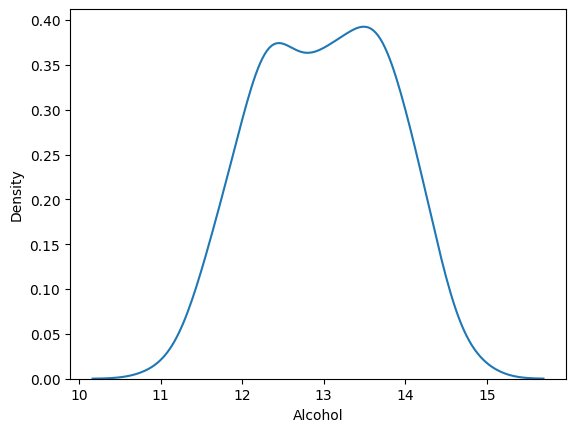

In [22]:
sns.kdeplot(df['Alcohol'])

<Axes: xlabel='Malic acid', ylabel='Density'>

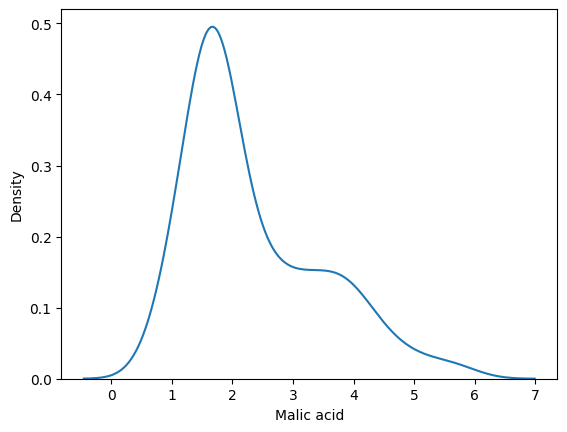

In [23]:
sns.kdeplot(df['Malic acid'])

<Axes: xlabel='Alcohol', ylabel='Malic acid'>

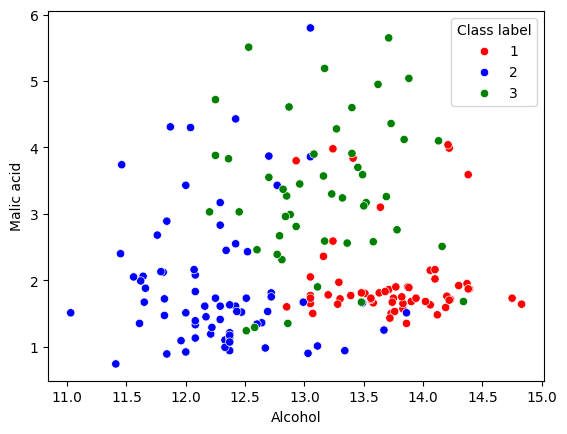

In [34]:
color_dict = {1:'red'  , 3:'green' , 2:'blue'}
sns.scatterplot(x=df['Alcohol'], y=df['Malic acid'], hue=df['Class label'], palette=color_dict)

In [25]:
from sklearn.model_selection import train_test_split

X_train , X_test , y_train , y_test = train_test_split(df.drop('Class label' , axis = 1) , df['Class label'] , test_size = 0.3 , random_state = 0 )

X_train.shape , X_test.shape

((124, 2), (54, 2))

In [35]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [37]:
feature_columns = df.drop('Class label' , axis = 1).columns
X_train_scaled = pd.DataFrame(X_train_scaled , columns = feature_columns)
X_test_scaled = pd.DataFrame(X_test_scaled , columns = feature_columns)

In [38]:
feature_columns = df.drop('Class label' , axis = 1).columns
X_train_scaled = pd.DataFrame(X_train , columns = feature_columns)
X_test_scaled = pd.DataFrame(X_test , columns = feature_columns)

In [39]:
np.round(X_train_scaled.describe() , 1)

,Alcohol,Malic acid
count,124.0,124.0
mean,0.5,0.3
std,0.2,0.2
min,0.0,0.0
25%,0.4,0.2
50%,0.5,0.2
75%,0.7,0.5
max,1.0,1.0


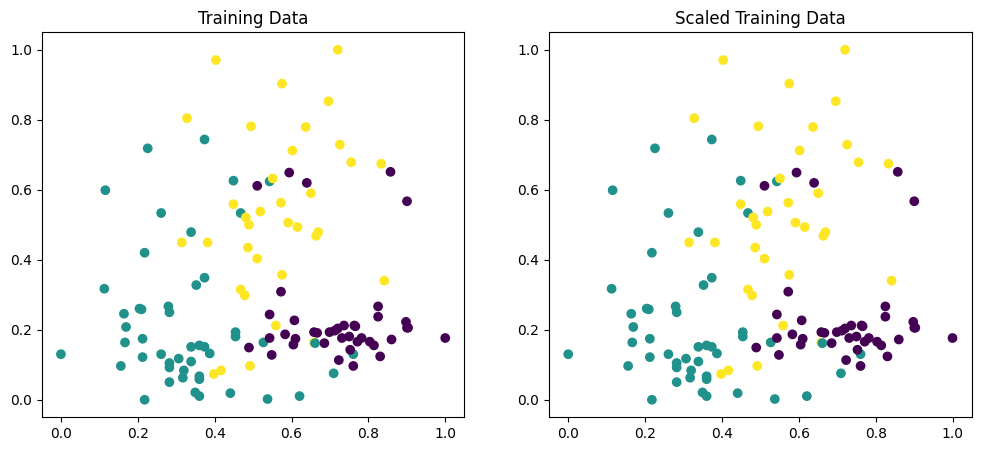

In [41]:
fig , (ax1 , ax2) = plt.subplots(ncols = 2 , figsize = (12,5))

ax1.scatter(X_train[:, 0] , X_train[:, 1] , c = y_train)
ax1.set_title('Training Data')

ax2.scatter(X_train_scaled['Alcohol'] , X_train_scaled['Malic acid'] , c = y_train)
ax2.set_title('Scaled Training Data')
plt.show()

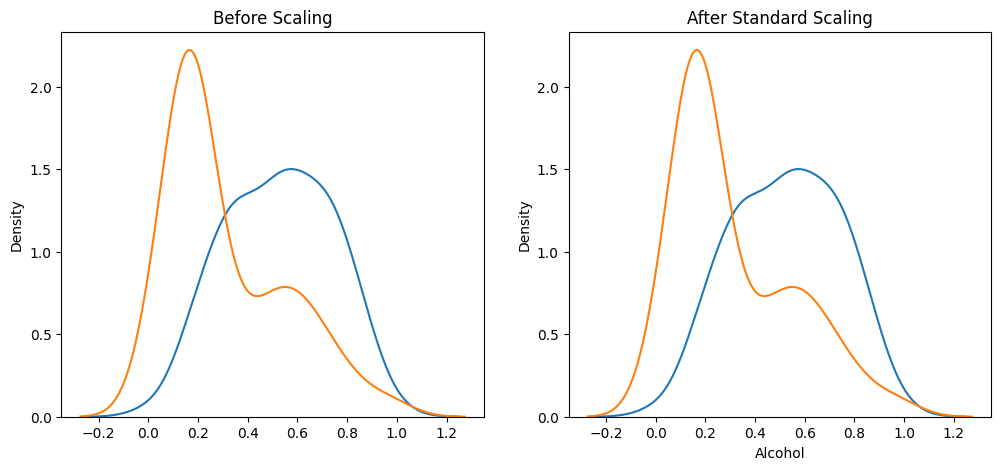

In [43]:

fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# before scaling
ax1.set_title('Before Scaling')
sns.kdeplot(X_train[:, 0], ax=ax1)
sns.kdeplot(X_train[:, 1], ax=ax1)

# after scaling
ax2.set_title('After Standard Scaling')
sns.kdeplot(X_train_scaled['Alcohol'], ax=ax2)
sns.kdeplot(X_train_scaled['Malic acid'], ax=ax2)
plt.show()

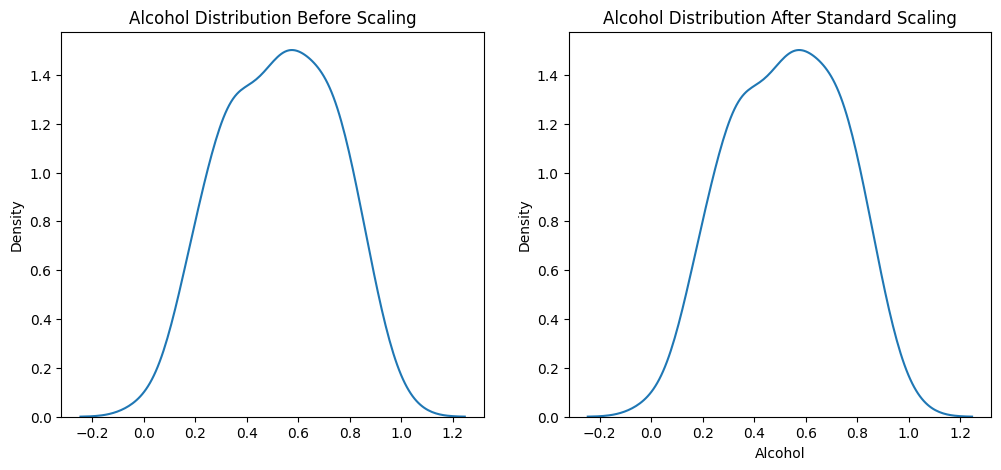

In [45]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# before scaling
ax1.set_title('Alcohol Distribution Before Scaling')
sns.kdeplot(X_train[:, 0], ax=ax1)

# after scaling
ax2.set_title('Alcohol Distribution After Standard Scaling')
sns.kdeplot(X_train_scaled['Alcohol'], ax=ax2)
plt.show()

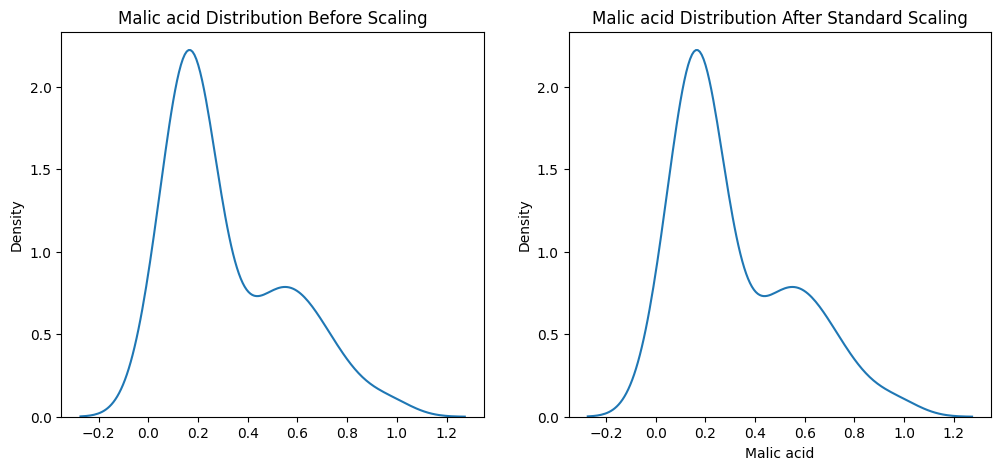

In [47]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# before scaling
ax1.set_title('Malic acid Distribution Before Scaling')
sns.kdeplot(X_train[:, 1], ax=ax1)

# after scaling
ax2.set_title('Malic acid Distribution After Standard Scaling')
sns.kdeplot(X_train_scaled['Malic acid'], ax=ax2)
plt.show()